In [1]:
"""
physics_aware_features.ipynb

Engineering physics aware features.
    - Transit Depth Consistency
    - Duration Consistency
    - Stellar Density Consistency
"""

'\nphysics_aware_features.ipynb\n\nEngineering physics aware features.\n    - Transit Depth Consistency\n    - Duration Consistency\n    - Stellar Density Consistency\n'

In [2]:
# ---- Imports ---- #
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# --- Physical Constants (SI Units) --- #
G_CONST = 6.6743e-11      # Gravitational constant in m^3 / (kg * s^2)
R_SUN = 6.957e8           # Radius of the Sun in meters
M_SUN = 1.9884e30         # Mass of the Sun in kilograms
AU_UNIT = 1.496e11        # Meters to Astronomical Units

# ---- Load Data ---- #
data_path : Path = Path("../data/physics/derived_params.csv")

df = pd.read_csv(data_path)

df.head()

,Unnamed: 0,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,phys_smass,phys_sma,Target
0,0,5980783,CONFIRMED,37.303320,7.7930,551.7,19.5,2.31,493.0,14.00,5646.0,4.550,0.817,0.863731,0.208074,1.0
1,1,10212441,CONFIRMED,15.044710,5.8230,97.9,23.4,1.51,931.0,177.24,5798.0,4.025,1.525,0.898409,0.115082,1.0
2,2,8395660,CONFIRMED,43.844397,6.8020,615.2,83.7,2.87,531.0,18.77,5854.0,4.406,1.012,0.951252,0.239314,1.0
3,3,8478994,CONFIRMED,21.301819,3.8763,87.3,32.4,0.72,564.0,23.89,5437.0,4.571,0.781,0.828393,0.141238,1.0
4,4,4833421,CONFIRMED,37.996237,6.7751,403.7,37.8,2.39,618.0,34.55,6038.0,4.284,1.191,0.994851,0.220804,1.0


In [3]:
# ---- Depth Anchoring ---- #

# Earth to Sun radius conversion constant
R_earth_to_sun = 0.009158

# Compute theoretical depth (ppm)
df['theo_theoretical_depth'] = ((df['koi_prad'] * R_earth_to_sun) / df['koi_srad'])**2 * 1e6

# Compute residue
df['phys_depth_residual'] = (df['koi_depth'] - df['theo_theoretical_depth']).abs()

# Drop temp coloumn --ignore for now
#df = df.drop(columns=['theoretical_depth'])

# View
display(df.head())

,Unnamed: 0,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,phys_smass,phys_sma,Target,theo_theoretical_depth,phys_depth_residual
0,0,5980783,CONFIRMED,37.303320,7.7930,551.7,19.5,2.31,493.0,14.00,5646.0,4.550,0.817,0.863731,0.208074,1.0,670.472740,118.772740
1,1,10212441,CONFIRMED,15.044710,5.8230,97.9,23.4,1.51,931.0,177.24,5798.0,4.025,1.525,0.898409,0.115082,1.0,82.227197,15.672803
2,2,8395660,CONFIRMED,43.844397,6.8020,615.2,83.7,2.87,531.0,18.77,5854.0,4.406,1.012,0.951252,0.239314,1.0,674.534313,59.334313
3,3,8478994,CONFIRMED,21.301819,3.8763,87.3,32.4,0.72,564.0,23.89,5437.0,4.571,0.781,0.828393,0.141238,1.0,71.279428,16.020572
4,4,4833421,CONFIRMED,37.996237,6.7751,403.7,37.8,2.39,618.0,34.55,6038.0,4.284,1.191,0.994851,0.220804,1.0,337.733046,65.966954


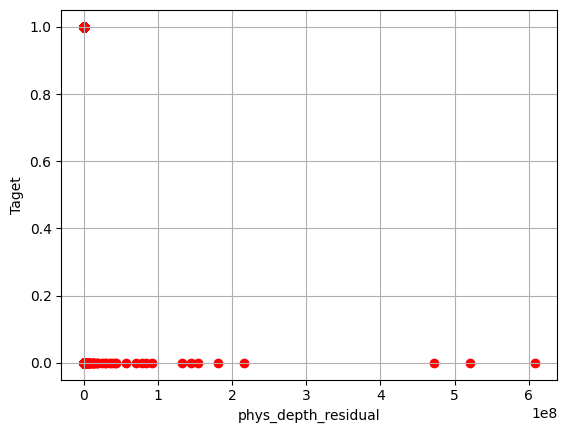

[[ 1.         -0.04302179]
 [-0.04302179  1.        ]]


In [4]:
# -- Visualize Depth Anchoring -- #
plt.figure()
plt.scatter(df["phys_depth_residual"], df["Target"], color = "red")

plt.xlabel("phys_depth_residual")
plt.ylabel("Taget")

plt.grid(True)
plt.show()

R = np.corrcoef(
    df["phys_depth_residual"],
    df["Target"]
)

print(R)


In [5]:
# ---- Duration Consistency Anchoring ---- #
# Reliant on a zero eccentricity assumption

# Unit conversion ratio
Rstar_by_AU_ratio = R_SUN / AU_UNIT

# Theoretical Anchor
df["theo_duration"] = (2 * df["koi_srad"] * df["koi_period"]) / (2 * np.pi * df["phys_sma"]) * Rstar_by_AU_ratio

# Compute residue
df["phys_duration_residual"] = (df["koi_duration"] - df["theo_duration"]).abs()

# View
display(df.head())

,Unnamed: 0,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,phys_smass,phys_sma,Target,theo_theoretical_depth,phys_depth_residual,theo_duration,phys_duration_residual
0,0,5980783,CONFIRMED,37.303320,7.7930,551.7,19.5,2.31,493.0,14.00,5646.0,4.550,0.817,0.863731,0.208074,1.0,670.472740,118.772740,0.216816,7.576184
1,1,10212441,CONFIRMED,15.044710,5.8230,97.9,23.4,1.51,931.0,177.24,5798.0,4.025,1.525,0.898409,0.115082,1.0,82.227197,15.672803,0.295111,5.527889
2,2,8395660,CONFIRMED,43.844397,6.8020,615.2,83.7,2.87,531.0,18.77,5854.0,4.406,1.012,0.951252,0.239314,1.0,674.534313,59.334313,0.274452,6.527548
3,3,8478994,CONFIRMED,21.301819,3.8763,87.3,32.4,0.72,564.0,23.89,5437.0,4.571,0.781,0.828393,0.141238,1.0,71.279428,16.020572,0.174364,3.701936
4,4,4833421,CONFIRMED,37.996237,6.7751,403.7,37.8,2.39,618.0,34.55,6038.0,4.284,1.191,0.994851,0.220804,1.0,337.733046,65.966954,0.303379,6.471721


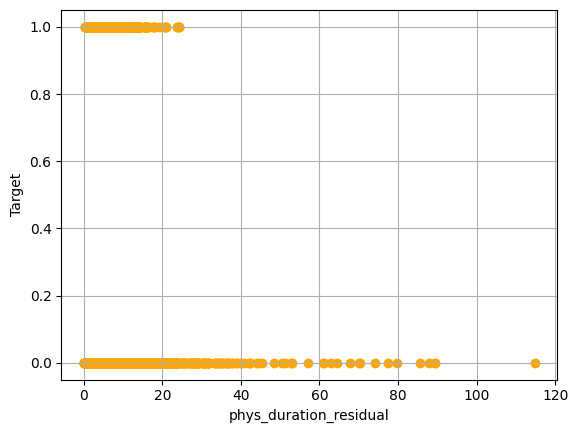

[[ 1.         -0.18817927]
 [-0.18817927  1.        ]]


In [6]:
# -- Visualise Duration Residue -- #
plt.figure()
plt.scatter(df["phys_duration_residual"], df["Target"], color = "orange")

plt.xlabel("phys_duration_residual")
plt.ylabel("Target")

plt.grid(True)
plt.show()

R = np.corrcoef(
    df["phys_duration_residual"],
    df["Target"]
)

print(R)



In [ ]:
# ---- Stellar Density Consistency ---- #
